In [1]:
# In this tutorial, we do sentiment analysis
# download the data
#!curl -O https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
#!tar xf aclImdb_v1.tar.gz

!curl -O https://www.cs.cornell.edu/people/pabo/movie-review-data/scale_data.tar.gz
!curl -O https://www.cs.cornell.edu/people/pabo/movie-review-data/scale_whole_review.tar.gz

!tar xf scale_data.tar.gz
!tar xf scale_whole_review.tar.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 3935k  100 3935k    0     0  7926k      0 --:--:-- --:--:-- --:--:-- 7918k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 8645k  100 8645k    0     0  14.0M      0 --:--:-- --:--:-- --:--:-- 14.0M


First, we have to load the data for which we provide the function below. Note how we also preprocess the text using gensim's simple_preprocess() function and how we already split the data into a train and test split.

In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.6 MB/s eta 0:00:00


In [4]:
import os
from gensim.utils import simple_preprocess
def load_data():
    examples, labels = [], []
    authors = os.listdir("scale_whole_review")
    for author in authors:
        path = os.listdir(os.path.join("scale_whole_review", author, "txt.parag"))
        fn_ids = os.path.join("scaledata", author, "id." + author)
        fn_ratings = os.path.join("scaledata", author, "rating." + author)
        with open(fn_ids) as ids, open(fn_ratings) as ratings:
            for idx, rating in zip(ids, ratings):
                labels.append(float(rating.strip()))
                filename_text = os.path.join("scale_whole_review", author, "txt.parag", idx.strip() + ".txt")
                with open(filename_text, encoding='latin-1') as f:
                    examples.append(" ".join(simple_preprocess(f.read())))
    return examples, labels

X,y  = load_data()
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print ("text:", X_train[0], "\nlabel:", y_train[0])

text: bloody child the director writer cinematographer nina menkes screenwriter tinka menkes editors nina and tina menkes cast tinka menkes captain sherry sibley murdered wife robert mueller murderer russ little sergeant jack hara enlisted man runtime mirage reviewed by dennis schwartz an amazingly strange film confusing and not thoroughly enjoyable but film found more interesting than thought possible at first viewing this experimental film in minimalist story telling film consisting of disturbing visualizations and almost no dialogue had concept that was greater than how the film turned out it felt at times like was watching paint dry on the wall but the reward for sitting through those excruciatingly redundant scenes was in seeing something different something that cast spell of sorcery over terrible incident as believe the film in its unique and sometimes shrill voice does justice in commenting on the violence in american society especially against women the film uses its impressio

In [5]:
# train a TF_IDF Vectorizer on X_train and vectorize X_train and X_test
from sklearn.feature_extraction.text import TfidfVectorizer

vec = TfidfVectorizer(min_df=0.01, # at min 1% of docs
                        max_df=.5,
                        stop_words='english',
                        ngram_range=(1,2))

##TODO train vectorizer
vec.fit(X_train)
##TODO transform X_train to TF-IDF values
X_train_tfidf = vec.transform(X_train)
##TODO transform X_test to TF-IDF values
X_test_tfidf = vec.transform(X_test)

In [6]:
##TODO scale both training and test data with the standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(with_mean=False)

scaler.fit(X_train_tfidf)
X_train_scaled = scaler.transform(X_train_tfidf)
X_test_scaled = scaler.transform(X_test_tfidf)

In [7]:
##TODO train an elastic net on the transformed output of the scaler
from sklearn.linear_model import ElasticNet

en = ElasticNet(alpha=0.01)

##TODO train the ElasticNet
en.fit(X_train_scaled, y_train)

##TODO predict the testset
y_pred = en.predict(X_test_scaled)

from sklearn.metrics import r2_score, mean_squared_error
##TODO print mean squared error and r2 score on the test set
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.016351788516409133
R2 Score: 0.49816933998129287


In [8]:
y_train = [1 if i >= 0.5 else 0 for i in y_train]
y_test = [1 if i >= 0.5 else 0 for i in y_test]

In [11]:
##TODO train logistic regression on X_train
from sklearn.linear_model import LogisticRegression
logistic_regression = LogisticRegression()

##TODO train a logistic regression
logistic_regression.fit(X_train_scaled, y_train)

##TODO predict the testset
y_pred_class = logistic_regression.predict(X_test_scaled)

##since we have continuous output, we need to post-process our labels into two classes. We choose a threshold of 0.5
def map_predictions(predicted):
    predicted = [1 if i > 0.5 else 0 for i in predicted]
    return predicted

##TODO print the accuracy of our classifier on the testset
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred_class))
## TODO print the 10 most informative words of the regression (the 10 words having the highest coefficients)
feature_names = vec.get_feature_names_out()
coefficients = logistic_regression.coef_[0]


Accuracy: 0.8062953995157385


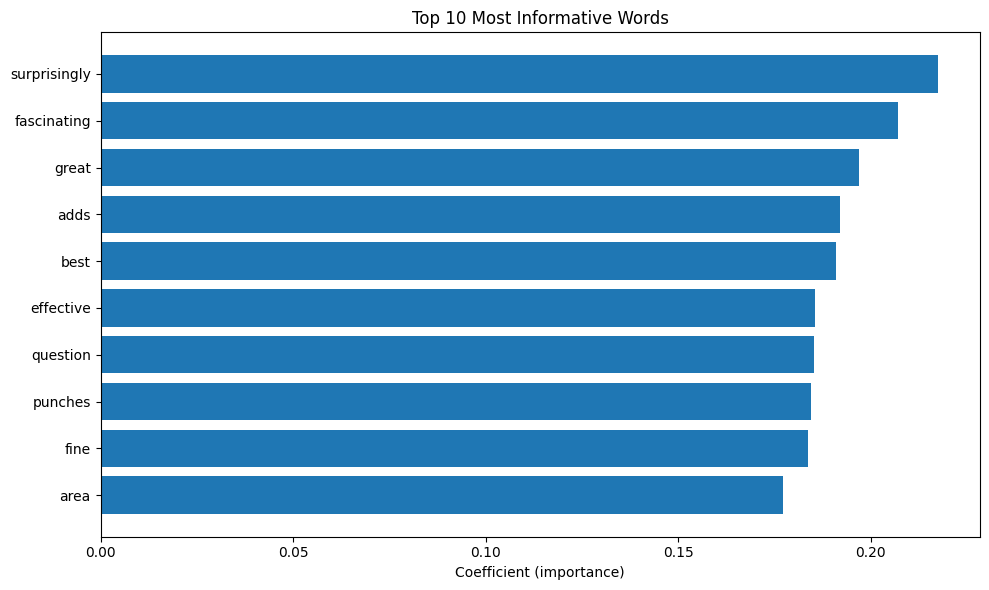

In [12]:
import matplotlib.pyplot as plt

top10_idx = coefficients.argsort()[-10:][::-1]
top10_words = [feature_names[idx] for idx in top10_idx]
top10_scores = [coefficients[idx] for idx in top10_idx]

plt.figure(figsize=(10, 6))
plt.barh(top10_words[::-1], top10_scores[::-1])  # reverse so highest is on top
plt.xlabel("Coefficient (importance)")
plt.title("Top 10 Most Informative Words")
plt.tight_layout()
plt.show()

In [14]:
#Import the AG news dataset (same as hw01)
#Download them from here
!wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv

import pandas as pd
import nltk
df = pd.read_csv('train.csv')

df.columns = ["label", "title", "lead"]
label_map = {1:"world", 2:"sport", 3:"business", 4:"sci/tech"}
def replace_label(x):
	return label_map[x]
df["label"] = df["label"].apply(replace_label)
df["text"] = df["title"] + " " + df["lead"]
df = df.sample(n=10000) # # only use 10K datapoints
df.head()

--2026-02-23 17:44:55--  https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 29470338 (28M) [text/plain]
Saving to: ‘train.csv’

train.csv           100%[===================>]  28.10M   161MB/s    in 0.2s    

2026-02-23 17:44:56 (161 MB/s) - ‘train.csv’ saved [29470338/29470338]



,label,title,lead,text
118176,business,Bed Bath Beyond Debt-Free,The leading home-goods retailer keeps its bala...,Bed Bath Beyond Debt-Free The leading home-g...
1607,business,Google IPO Under Threat Due to Shortage of Bids,Google has asked the Securities and Exchange C...,Google IPO Under Threat Due to Shortage of Bid...
60443,business,Crude climbs ahead of inventory data,SAN FRANCISCO (AFX) -- Crude-oil futures climb...,Crude climbs ahead of inventory data SAN FRANC...
58888,world,US airstrikes leave 11 dead in Iraq,"FALLUJAH, Oct 12: US planes hammered guerilla ...","US airstrikes leave 11 dead in Iraq FALLUJAH, ..."
46542,sci/tech,Recruiter Puts Its Money Where Its Workers Are,Clint Heiden's two-month-old recruiting firm o...,Recruiter Puts Its Money Where Its Workers Are...


In [15]:
# create a new variable "business" that takes value 1 if the label is business and 0 otherwise
df['business'] = df['label'].apply(lambda x: int(x=='business'))
y = df['business'].values
df['business'].head()

,business
118176,1
1607,1
60443,1
58888,0
46542,0


In [16]:
import spacy
nlp = spacy.load('en_core_web_sm')
from sklearn.feature_extraction.text import CountVectorizer

# pre-process text as you did in HW02
def tokenize(x):
    return [w.lemma_.lower() for w in nlp(x) if not w.is_stop and not w.is_punct and not w.is_digit]
df["tokens"] = df["text"].apply(tokenize)
df["preprocessed_text"] = df["tokens"].apply(lambda x: " ".join(x))

##TODO vectorize the pre-processed text using CountVectorizer
count_vec = CountVectorizer(max_features=5000)

X_counts = count_vec.fit_transform(df["preprocessed_text"])

In [20]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchsummary import summary

import math
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## TODO build a MLP model with at least 2 hidden layers with ReLU activation, followed by dropout and an output layer with sigmoid activation
X_train, X_val, y_train, y_val = train_test_split(
    X_counts.toarray(),
    y,
    test_size=0.2,
    random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 256)
        self.fc2 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.3)
        self.out = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = torch.sigmoid(self.out(x))
        return x

input_dim = X_train.shape[1]
model = MLP(input_dim)

## TODO summarize the model using torchsummary
summary(model, (input_dim,))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]       1,280,256
           Dropout-2                  [-1, 256]               0
            Linear-3                  [-1, 128]          32,896
           Dropout-4                  [-1, 128]               0
            Linear-5                    [-1, 1]             129
Total params: 1,313,281
Trainable params: 1,313,281
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.02
Forward/backward pass size (MB): 0.01
Params size (MB): 5.01
Estimated Total Size (MB): 5.03
----------------------------------------------------------------


In [21]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

patience = 5
best_val_loss = float("inf")
counter = 0
best_model_state = None

# Track metrics for plotting
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(50):
    # --- Training ---
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

    train_acc = accuracy_score(y_train.numpy(), (outputs.detach() > 0.5).float().numpy())

    # --- Validation ---
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_acc = accuracy_score(y_val.numpy(), (val_outputs > 0.5).float().numpy())

    # --- Save metrics ---
    history["train_loss"].append(loss.item())
    history["val_loss"].append(val_loss.item())
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:02d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # --- Early stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        counter = 0
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered.")
        break

model.load_state_dict(best_model_state)

# --- Final validation accuracy ---
model.eval()
with torch.no_grad():
    val_pred = (model(X_val) > 0.5).float()

print("Validation Accuracy:", accuracy_score(y_val.numpy(), val_pred.numpy()))

Epoch 01 | Train Loss: 0.6812 | Val Loss: 0.6676 | Train Acc: 0.7442 | Val Acc: 0.7600
Epoch 02 | Train Loss: 0.6690 | Val Loss: 0.6546 | Train Acc: 0.7441 | Val Acc: 0.7600
Epoch 03 | Train Loss: 0.6563 | Val Loss: 0.6403 | Train Acc: 0.7441 | Val Acc: 0.7605
Epoch 04 | Train Loss: 0.6420 | Val Loss: 0.6234 | Train Acc: 0.7441 | Val Acc: 0.7605
Epoch 05 | Train Loss: 0.6252 | Val Loss: 0.6031 | Train Acc: 0.7449 | Val Acc: 0.7630
Epoch 06 | Train Loss: 0.6051 | Val Loss: 0.5793 | Train Acc: 0.7462 | Val Acc: 0.7660
Epoch 07 | Train Loss: 0.5813 | Val Loss: 0.5521 | Train Acc: 0.7511 | Val Acc: 0.7715
Epoch 08 | Train Loss: 0.5545 | Val Loss: 0.5222 | Train Acc: 0.7555 | Val Acc: 0.7795
Epoch 09 | Train Loss: 0.5246 | Val Loss: 0.4906 | Train Acc: 0.7676 | Val Acc: 0.7915
Epoch 10 | Train Loss: 0.4936 | Val Loss: 0.4584 | Train Acc: 0.7854 | Val Acc: 0.8035
Epoch 11 | Train Loss: 0.4613 | Val Loss: 0.4266 | Train Acc: 0.8006 | Val Acc: 0.8185
Epoch 12 | Train Loss: 0.4280 | Val Loss: 0

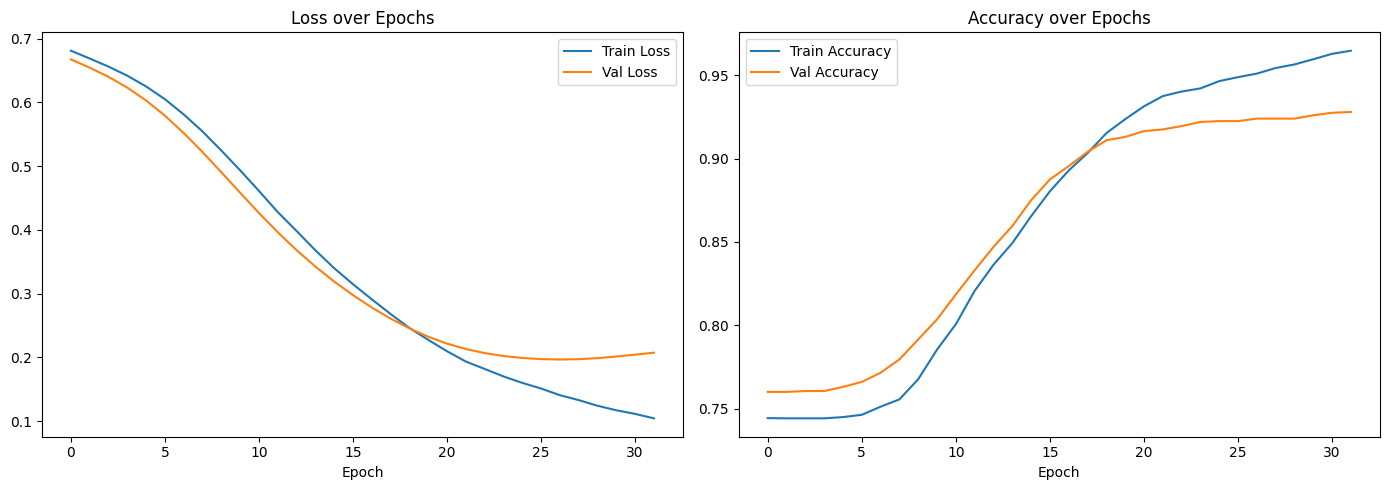

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"],   label="Val Loss")
ax1.set_title("Loss over Epochs")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(history["train_acc"], label="Train Accuracy")
ax2.plot(history["val_acc"],   label="Val Accuracy")
ax2.set_title("Accuracy over Epochs")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()